In [11]:
from gensim.test.utils import common_texts
from gensim.models import Word2Vec
import numpy as np

In [12]:
# Word2Vec Modell definieren und trainieren
model = Word2Vec(
    sentences=common_texts,
    vector_size=50,
    window=3,
    min_count=1,
    workers=1
)

In [13]:
print(model.wv.key_to_index)


{'system': 0, 'graph': 1, 'trees': 2, 'user': 3, 'minors': 4, 'eps': 5, 'time': 6, 'response': 7, 'survey': 8, 'computer': 9, 'interface': 10, 'human': 11}


In [14]:
print(model.wv["computer"])

[ 0.00805625  0.0086974   0.01992054 -0.00895008 -0.00277934 -0.0146389
 -0.0194013  -0.0181658  -0.00204611 -0.01301037  0.00970228 -0.01233164
  0.00503984  0.00147931 -0.00678628 -0.00195902  0.01996406  0.0182971
 -0.00892626  0.01817134 -0.01128681  0.0118653  -0.00619624  0.0068655
  0.00603621  0.01380494 -0.00474915  0.01755518  0.01518327 -0.01910085
 -0.01602108 -0.01528024  0.00584822 -0.00559107 -0.01386307 -0.01626126
  0.0166232   0.00398214 -0.01866146 -0.00958822  0.0062753  -0.00942916
  0.01056476 -0.00846935  0.00528513 -0.01609606  0.01242339  0.00964058
  0.00157484  0.00602865]


In [15]:
print(model.wv.most_similar("user"))

[('response', 0.04491858929395676), ('survey', -0.010279342532157898), ('system', -0.014444791711866856), ('interface', -0.023244768381118774), ('time', -0.04404586926102638), ('human', -0.09487428516149521), ('computer', -0.1224871352314949), ('trees', -0.1551731526851654), ('graph', -0.17425437271595), ('minors', -0.20604662597179413)]


In [16]:
# pretrained models
import gensim.downloader as gdw
gdw.info()["models"].keys()

dict_keys(['fasttext-wiki-news-subwords-300', 'conceptnet-numberbatch-17-06-300', 'word2vec-ruscorpora-300', 'word2vec-google-news-300', 'glove-wiki-gigaword-50', 'glove-wiki-gigaword-100', 'glove-wiki-gigaword-200', 'glove-wiki-gigaword-300', 'glove-twitter-25', 'glove-twitter-50', 'glove-twitter-100', 'glove-twitter-200', '__testing_word2vec-matrix-synopsis'])

In [17]:
google_model = gdw.load('word2vec-google-news-300')

In [18]:
google_model.most_similar(positive=['king', 'woman'], negative=['man'], topn=3)

[('queen', 0.7118192911148071),
 ('monarch', 0.6189674139022827),
 ('princess', 0.5902431011199951)]

In [19]:
google_model.most_similar(positive=['france', 'athens'], negative=['paris'], topn=3)

[('england', 0.5069623589515686),
 ('european', 0.5044828057289124),
 ('italy', 0.4999608099460602)]

In [20]:
google_model.most_similar(positive=['doctor', 'woman'], negative=['man'], topn=3)

[('gynecologist', 0.7093891501426697),
 ('nurse', 0.647728681564331),
 ('doctors', 0.6471461057662964)]

In [21]:
# visualization utility function.
# This should work as is.

from sklearn.manifold import TSNE
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
sns.set_theme(rc={'figure.figsize':(11.7,8.27)})

def tsne_scatterplot(model, search_word, topn):
    labels = [search_word]
    tokens = [model[search_word]]
    similar = [1]
    close_words = model.similar_by_word(search_word, topn=topn)
    for word in close_words:
        tokens.append(model[word[0]])
        labels.append(word[0])
        similar.append(word[1])

    tsne_model = TSNE(n_components=2, perplexity=topn, init='pca')
    coordinates = tsne_model.fit_transform(np.array(tokens))
    df = pd.DataFrame({'x': [x for x in coordinates[:, 0]],
                       'y': [y for y in coordinates[:, 1]],
                       'words': labels,
                       'similarity': similar}
                      )
    fig, ax = plt.subplots()
    plot = ax.scatter(df.x, df.y, c=df.similarity, cmap='Reds')
    for i in range(len(df)):
        ax.annotate("  {} ({:.2f})".format(df.words[i].title(),
                                           df.similarity[i]),
                    (df.x[i], df.y[i]))

    plt.colorbar(mappable=plot, ax=ax)
    plt.title('t-SNE visualization for {}'.format(search_word))
    plt.show()

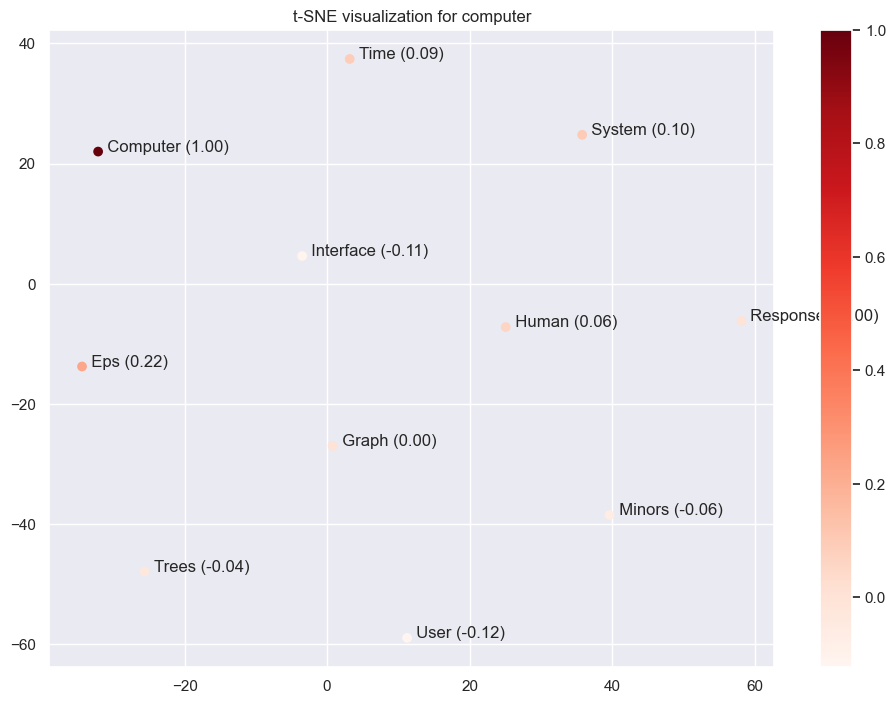

In [22]:
tsne_scatterplot(model.wv, "computer", 10)

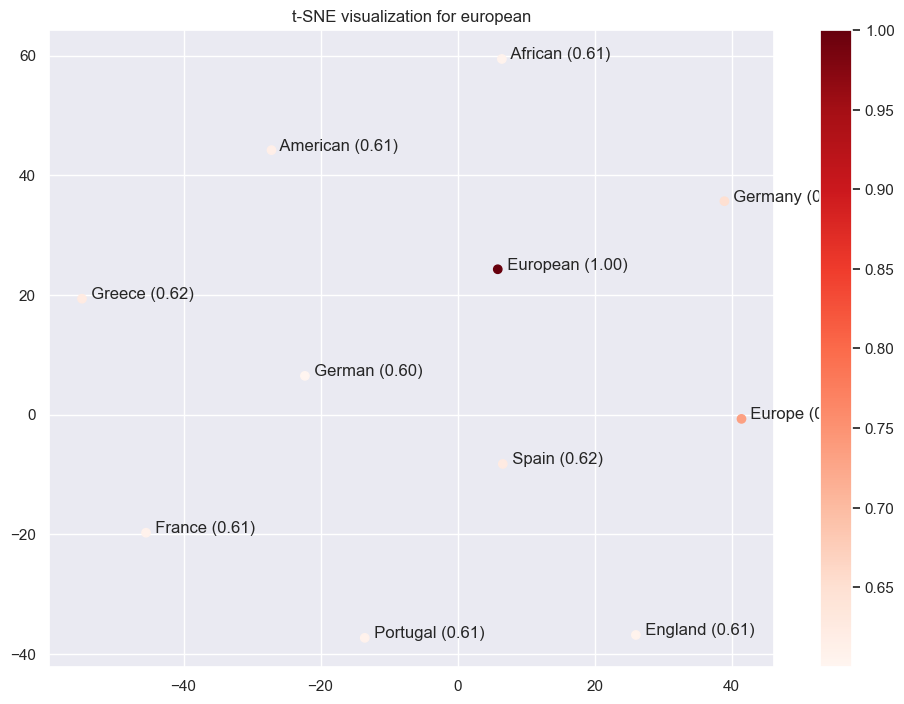

In [23]:
tsne_scatterplot(google_model, "european", 10)

In [24]:
from collections import Counter, defaultdict, deque
from tqdm import tqdm
import torch
from datasets import load_dataset

In [25]:
ds = load_dataset("afmck/text8")

In [26]:
text = ds["train"][0]["text"]
# Wörter erzeugen
words = text.split()
word_counts = Counter(words)
print(len(word_counts))

239974


In [ ]:
vocab_size = 2**14
most_common_words = word_counts.most_common(vocab_size - 1)

# Vokabular aus häufigsten Wörtern bauen
id_to_word = ["<unk>"] + [word for word, count in most_common_words]
unk_index = 0

# Wenn Wort nicht in Vokabular dann index 0
word_to_id = defaultdict(lambda: unk_index)

# Auf alle Wörter anwenden
for idx, word in enumerate(id_to_word):
    word_to_id[word] = idx

# Wörter in Zahlen codieren
encoded_words = [word_to_id[token] for token in words]

In [28]:
# SkipGram Paare erzeugen
context_size = 1
skipgram_pairs = []

for i in tqdm(range(len(encoded_words))):
    center_word = encoded_words[i]
    # linkes Fenster beschränkt auf 0
    left_context = deque(
        encoded_words[max(0, i - context_size):i],
        maxlen=context_size
    )
    # rechtes Fenster beschränkt auf Länge
    right_context = deque(
        encoded_words[i + 1:i + context_size + 1],
        maxlen=context_size
    )

    for context_word in left_context:
        skipgram_pairs.append((center_word, context_word))

    for context_word in right_context:
        skipgram_pairs.append((center_word, context_word))

100%|██████████| 15301749/15301749 [00:26<00:00, 570869.65it/s]


In [29]:
from torch.utils.data import Dataset

In [30]:
# Dataset erstellen
class Dataset(Dataset):
    def __init__(self, pairs):
        self.pairs = pairs

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        center_word, context_word = self.pairs[idx]
        return torch.tensor(center_word, dtype=torch.long), torch.tensor(context_word, dtype=torch.long)

In [31]:
smaller_pairs = skipgram_pairs[:500]
dataset = Dataset(skipgram_pairs)

In [32]:
print(len(dataset))
print(dataset[0])

30603496
(tensor(4813), tensor(3139))


In [ ]:
import torch.nn as nn

class SkipGramModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim):
        super().__init__()

        # center embedding u
        self.center_embedding = nn.Embedding(vocab_size, embedding_dim)
        # context embeding v
        self.context_embedding = nn.Embedding(vocab_size, embedding_dim)

    # optimization
    def forward(self, center_word):
        # u bestimmen
        center_vector = self.center_embedding(center_word)

        # dot product u^T * v berechnen um Vergleich zwischen center_vector und allen context_vectors zu erhalten
        value = torch.matmul(center_vector, self.context_embedding.weight.T)

        return value

# CrossEntropyLoss == LogSoftmax + Negative Loglikelihood Loss
criterion = nn.CrossEntropyLoss()

In [34]:
from torch.utils.data import DataLoader

dataloader = DataLoader(
    dataset,
    batch_size=512,
    shuffle=True
)

In [35]:
model = SkipGramModel(vocab_size, 16)
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

In [ ]:
# Training
num_epochs = 3

for epoch in range(num_epochs):
    total_loss = 0

    for center, context in dataloader:
        optimizer.zero_grad()

        # u^T * v
        value = model(center)

        loss = criterion(value, context)

        loss.backward()
        
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(dataloader)
    print(f"Epoch: {epoch+1}, Loss: {avg_loss}")

KeyboardInterrupt: 

In [ ]:
# model evaluation
import torch.nn.functional as F

# Zugriff auf die Embedding Vektoren über Matrix
embedding_matrix = model.center_embedding.weight

def most_similar_words(word):
    word_id = word_to_id[word]
    # Wortvektor holen und in 2D Tensor umwandlen
    word_vector = embedding_matrix[word_id].unsqueeze(0)

    # Ähnlichkeit durch co-occurance berechnen
    similarity = F.cosine_similarity(word_vector, embedding_matrix, dim=1)

    # Wort selbst ausschließen
    similarity[word_id] = -1

    # ids für ähnlichste Wörter holen und in Liste umwandeln
    similar_words = torch.topk(similarity, 5).indices.tolist()
    results = []

    for i in similar_words:
        results.append((id_to_word[i], similarity[i].item()))

    return results

In [ ]:
most_similar_words("king")

[('ibm', 0.7717299461364746),
 ('wikisource', 0.7717228531837463),
 ('illuminated', 0.7647844552993774),
 ('rainy', 0.7575951814651489),
 ('online', 0.7429097890853882)]

In [ ]:
def analogy(word_a, word_b, word_c):
    # Wortvektoren erstellen
    vec_a = embedding_matrix[word_to_id[word_a]]
    vec_b = embedding_matrix[word_to_id[word_b]]
    vec_c = embedding_matrix[word_to_id[word_c]]

    # Vektor für Vergleich berechnen und in 2D Tensor umwandeln
    final_vector = (vec_a - vec_b + vec_c).unsqueeze(0)

    # Ähnlichkeit durch co-occurance berechnen
    similarity = F.cosine_similarity(final_vector, embedding_matrix, dim=1)

    # Eingabewörter ausschließen
    similarity[word_to_id[word_a]] = -1
    similarity[word_to_id[word_b]] = -1
    similarity[word_to_id[word_c]] = -1

    # ids für ähnlichste Wörter holen und in Liste umwandeln
    most_similar_words = torch.topk(similarity, 5).indices.tolist()
    results = []

    for i in most_similar_words:
        results.append((id_to_word[i], similarity[i].item()))

    return results

In [ ]:
analogy("king", "man", "woman")

[('correspondent', 0.8094637393951416),
 ('supreme', 0.7998091578483582),
 ('brien', 0.7955535650253296),
 ('as', 0.7847916483879089),
 ('quartz', 0.7654989361763)]

In [ ]:
# noise distribution für Auswahl negativer pairs
id_counts = Counter(encoded_words)

noise_distribution = torch.zeros(len(id_to_word), dtype=torch.float)

# Wort ids und Häufigkeit bestimmen
for word_id, count in id_counts.items():
    noise_distribution[word_id] = count

# 3/4 damit seltene Wörter öfter als negative gesampled werden
noise_distribution = noise_distribution ** 0.75
# Wahrscheinlichkeitsverteilung
noise_distribution = noise_distribution / noise_distribution.sum()

In [ ]:
# SGNS Modell
class SGNSModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim):
        super().__init__()

        # center embedding u
        self.center_embedding = nn.Embedding(vocab_size, embedding_dim)
        # context embedding v
        self.context_embedding = nn.Embedding(vocab_size, embedding_dim)

    def forward(self, center_word, context_word, negative_words):
        # u bestimmen
        center_vector = self.center_embedding(center_word)

        # v_c bestimmen
        context_vector = self.context_embedding(context_word)

        # v_j für negative_words bestimmen
        negative_vectors = self.context_embedding(negative_words)

        # positive value mit u^T * v_c berechnen
        positive_value = torch.sum(center_vector * context_vector, dim=1)

        # negative value mit u^T * v_j berechnen
        negative_value = torch.sum(center_vector.unsqueeze(1) * negative_vectors, dim=2)

        # -log sigma(u^T * v_c) - sum (logsigma(-u^T * v_j))
        
        # log sigma(u^T * v_c)
        positive_loss = F.logsigmoid(positive_value)
        # sum (log sigma -u^T * v_j)
        negative_loss = F.logsigmoid(-negative_value).sum(dim=1)

        loss = -(positive_loss + negative_loss).mean()

        return loss

In [ ]:
model = SGNSModel(len(id_to_word), 16)
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

In [ ]:
# Training
num_epochs = 3
num_negative_samples = 5

for epoch in range(num_epochs):
    total_loss = 0

    for center, context in dataloader:
        optimizer.zero_grad()

        # negative samples für Wortpaar erzeugen
        negative_words = torch.multinomial(
            noise_distribution,
            center.size(0) * num_negative_samples,
            replacement=True
        ).view(center.size(0), num_negative_samples)

        loss = model(center, context, negative_words)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(dataloader)
    print(f"Epoch: {epoch+1}, Loss: {avg_loss}")

KeyboardInterrupt: 

In [ ]:
# Datensatz wikitext103
ds_wikitext = load_dataset("Salesforce/wikitext", "wikitext-103-v1")

In [ ]:
text = ds_wikitext["train"]["text"]
print(len(text))
print(type(text))
print(text[:5])

1801350
<class 'datasets.arrow_dataset.Column'>
['', ' = Valkyria Chronicles III = \n', '', ' Senjō no Valkyria 3 : <unk> Chronicles ( Japanese : 戦場のヴァルキュリア3 , lit . Valkyria of the Battlefield 3 ) , commonly referred to as Valkyria Chronicles III outside Japan , is a tactical role @-@ playing video game developed by Sega and Media.Vision for the PlayStation Portable . Released in January 2011 in Japan , it is the third game in the Valkyria series . Employing the same fusion of tactical and real @-@ time gameplay as its predecessors , the story runs parallel to the first game and follows the " Nameless " , a penal military unit serving the nation of Gallia during the Second Europan War who perform secret black operations and are pitted against the Imperial unit " <unk> Raven " . \n', " The game began development in 2010 , carrying over a large portion of the work done on Valkyria Chronicles II . While it retained the standard features of the series , it also underwent multiple adjustme

In [ ]:
text = [i for i in text if i.strip() != '']
print(len(text))
print(type(text))
print(text[:10])

1165029
<class 'list'>
[' = Valkyria Chronicles III = \n', ' Senjō no Valkyria 3 : <unk> Chronicles ( Japanese : 戦場のヴァルキュリア3 , lit . Valkyria of the Battlefield 3 ) , commonly referred to as Valkyria Chronicles III outside Japan , is a tactical role @-@ playing video game developed by Sega and Media.Vision for the PlayStation Portable . Released in January 2011 in Japan , it is the third game in the Valkyria series . Employing the same fusion of tactical and real @-@ time gameplay as its predecessors , the story runs parallel to the first game and follows the " Nameless " , a penal military unit serving the nation of Gallia during the Second Europan War who perform secret black operations and are pitted against the Imperial unit " <unk> Raven " . \n', " The game began development in 2010 , carrying over a large portion of the work done on Valkyria Chronicles II . While it retained the standard features of the series , it also underwent multiple adjustments , such as making the game mor

In [ ]:
string_text = " ".join(text)
print(type(string_text))
print(string_text[:500])

<class 'str'>
 = Valkyria Chronicles III = 
  Senjō no Valkyria 3 : <unk> Chronicles ( Japanese : 戦場のヴァルキュリア3 , lit . Valkyria of the Battlefield 3 ) , commonly referred to as Valkyria Chronicles III outside Japan , is a tactical role @-@ playing video game developed by Sega and Media.Vision for the PlayStation Portable . Released in January 2011 in Japan , it is the third game in the Valkyria series . Employing the same fusion of tactical and real @-@ time gameplay as its predecessors , the story runs parall


In [ ]:
from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import Whitespace

In [ ]:
# unbekannte Wörter als <unk>
tokenizer = Tokenizer(BPE(unk_token="<unk>"))
# tokenziser wird an Leerzeichen aufgteilt
tokenizer.pre_tokenizer = Whitespace()

In [ ]:
trainer = BpeTrainer(
    vocab_size=2**14,
    special_tokens=["<unk>"]
)

In [ ]:
# tokenizer trainieren
tokenizer.train_from_iterator([string_text], trainer=trainer)

In [ ]:
encoded = tokenizer.encode(string_text)
tokens = encoded.tokens

print("Anzahl Tokens:", len(tokens))
print("Erste 50 Tokens:")
print(tokens[:50])

In [ ]:
token_counts = Counter(tokens)

vocab_size = 2**14
most_common_tokens = token_counts.most_common(vocab_size - 1)

# Vokabular aus häufigsten Wörtern bauen
id_to_token = ["<unk>"] + [token for token, count in most_common_tokens]
unk_index = 0

# Wenn Wort nicht in Vokabular dann index 0
token_to_id = defaultdict(lambda: unk_index)

# Auf alle Wörter anwenden
for idx, token in enumerate(id_to_token):
    token_to_id[token] = idx

# Wörter in Zahlen codieren
encoded_tokens = [token_to_id[token] for token in tokens]

In [ ]:
# SkipGram Paare erzeugen
context_size = 1
skipgram_pairs = []

for i in tqdm(range(len(encoded_tokens))):
    center_token = encoded_tokens[i]
    # linkes Fenster beschränkt auf 0
    left_context = deque(
        encoded_tokens[max(0, i - context_size):i],
        maxlen=context_size
    )
    # rechtes Fenster beschränkt auf Länge
    right_context = deque(
        encoded_tokens[i + 1:i + context_size + 1],
        maxlen=context_size
    )

    for context_token in left_context:
        skipgram_pairs.append((center_token, context_token))

    for context_token in right_context:
        skipgram_pairs.append((center_token, context_token))

In [ ]:
# neues Datset erzeugen
dataloader = DataLoader(
    dataset,
    batch_size=512,
    shuffle=True
)

In [ ]:
# neues Modell und optimizer erzeugen
model = SkipGramModel(vocab_size, 16)
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

In [ ]:
# Training neu laufen lassen
num_epochs = 3

for epoch in range(num_epochs):
    total_loss = 0

    for center, context in dataloader:
        optimizer.zero_grad()

        # u^T * v
        value = model(center)

        loss = criterion(value, context)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(dataloader)
    print(f"Epoch: {epoch+1}, Loss: {avg_loss}")

In [ ]:
# noise distribution für Auswahl negativer pairs
id_counts = Counter(encoded_tokens)

noise_distribution = torch.zeros(len(id_to_token), dtype=torch.float)

# Token ids und Häufigkeit bestimmen
for token_id, count in id_counts.items():
    noise_distribution[token_id] = count

# 3/4 damit seltene Tokens öfter als negative gesampled werden
noise_distribution = noise_distribution ** 0.75

# Wahrscheinlichkeitsverteilung
noise_distribution = noise_distribution / noise_distribution.sum()

In [ ]:
model = SGNSModel(len(id_to_token), 16)
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

In [ ]:
# Training
num_epochs = 3
num_negative_samples = 5

for epoch in range(num_epochs):
    total_loss = 0

    for center, context in dataloader:
        optimizer.zero_grad()

        # negative samples für Wortpaar erzeugen
        negative_tokens = torch.multinomial(
            noise_distribution,
            center.size(0) * num_negative_samples,
            replacement=True
        ).view(center.size(0), num_negative_samples)

        loss = model(center, context, negative_tokens)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(dataloader)
    print(f"Epoch: {epoch+1}, Loss: {avg_loss}")